In [1]:
pip install cma

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import cma
from preprocessing import load_data, normalize
from models import Classifier
import matplotlib.pyplot as plt
import seaborn as sns

# Basic settings
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataroot = "MachineLearningCVE/"
X, y = load_data(dataroot)
X = normalize(X)
print(f"Data shape: {X.shape}, Total samples: {len(y)}")

input_dim = X.shape[1]
num_classes = len(np.unique(y))

# Feature Index Definitions
FLOW_DURATION, TOTAL_FWD_PACKETS, TOTAL_BWD_PACKETS, FLOW_IAT_MEAN = 0, 1, 2, 10
allowed_idx = [FLOW_DURATION, TOTAL_FWD_PACKETS, TOTAL_BWD_PACKETS, FLOW_IAT_MEAN]

# Semantic constraints
MAX_TOTAL_DELAY = 0.5
MAX_PADDING = 5
MIN_PACKET_COUNT = 0
MIN_DURATION = 0.0

MachineLearningCVE/*.csv
['MachineLearningCVE\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'MachineLearningCVE\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'MachineLearningCVE\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'MachineLearningCVE\\Monday-WorkingHours.pcap_ISCX.csv', 'MachineLearningCVE\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'MachineLearningCVE\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'MachineLearningCVE\\Tuesday-WorkingHours.pcap_ISCX.csv', 'MachineLearningCVE\\Wednesday-workingHours.pcap_ISCX.csv']
There are 2830743 flow records with 79 feature dimension
Data loaded.
Data preprocessing started...
Stripped column names with whitespaces
remove unnecessary columns:  ['Flow Packets/s', 'Flow Bytes/s', 'Label']
There are 0 nan entries
Converted to numeric
Data shape: (2830743, 76), Total samples: 2830743


In [3]:
# Initialize and Load Model
clf = Classifier(
    method="cnn5",
    input_dim=input_dim,
    num_classes=num_classes,
    num_epochs=60,
    batch_size=5120,
    lr=1e-3,
    reg=1e-3,
    runs_dir=None,
    seed=SEED
)

checkpoint_path = os.path.join("checkpoints", "baseline_cnn_cicids2017.pth")
checkpoint = torch.load(checkpoint_path, map_location=device)
clf.model.load_state_dict(checkpoint["model_state_dict"])
clf.model.to(device)
clf.model.eval()
print("Model loaded successfully from checkpoint.")

Model loaded successfully from checkpoint.


C:\Users\jchen71\AppData\Local\Temp\ipykernel_107652\4031568502.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=de

In [4]:
def build_adv_samples(x_orig_batch, delta_batch, allowed_idx):
    # Constructs adversarial samples by applying perturbations to the original features.
    batch, D = x_orig_batch.shape
    pop_size = delta_batch.shape[1]
    # Broadcast original samples to match population size
    x_adv = x_orig_batch.unsqueeze(1).repeat(1, pop_size, 1)
    
    # Apply perturbations: [Duration, Fwd_Pkts, Bwd_Pkts, IAT_Mean]
    x_adv[:, :, FLOW_DURATION] += delta_batch[:, :, 0]
    # Realistic constraint: Packet counts must be integers AND non-negative (clamped at min=0)
    x_adv[:, :, TOTAL_FWD_PACKETS] += torch.clamp(torch.round(delta_batch[:, :, 1]), min=0) 
    x_adv[:, :, TOTAL_BWD_PACKETS] += torch.clamp(torch.round(delta_batch[:, :, 2]), min=0) 
    x_adv[:, :, FLOW_IAT_MEAN] += delta_batch[:, :, 3]
    
    # Physical consistency: Duration can only increase (delay)
    x_adv[:, :, FLOW_DURATION] = torch.clamp(x_adv[:, :, FLOW_DURATION], min=x_orig_batch[:, FLOW_DURATION].unsqueeze(1))
    
    return x_adv

def attack_objective_gpu(x_orig_batch, delta_batch, allowed_idx):
    """Batch objective function with semantic penalty for CMA-ES"""
    x_adv = build_adv_samples(x_orig_batch, delta_batch, allowed_idx)
    b, p, D = x_adv.shape
    x_adv_flat = x_adv.view(b * p, D)
    
    # 1. Classification Loss (Target: Benign Class 0)
    logits = clf.model(x_adv_flat)
    target = torch.zeros(b * p, dtype=torch.long, device=device) 
    loss_ce = F.cross_entropy(logits, target, reduction='none').view(b, p)
    
    # 2. Semantic Constraint Penalty
    penalty = torch.zeros((b, p), device=device)
    # Penalty for exceeding max delay
    penalty += torch.clamp(delta_batch[:, :, 0] - MAX_TOTAL_DELAY, min=0) * 10.0
    # Penalty for exceeding max padding (sum of Fwd and Bwd increments)
    penalty += torch.clamp(torch.sum(torch.abs(delta_batch[:, :, 1:3]), dim=2) - MAX_PADDING, min=0) * 10.0
    # Penalty for violating minimum physical duration
    penalty += torch.clamp(MIN_DURATION - x_adv[:, :, FLOW_DURATION], min=0) * 10.0
    
    return loss_ce + penalty

In [5]:
CMA_MAXITER = 8  
BATCH_SAMPLES = 64  
POP_SIZE = 8


#MAX_ATTACK_SAMPLES = 10000           
#malicious_indices = np.where(y != 0)[0][:MAX_ATTACK_SAMPLES]

malicious_indices = np.where(y != 0)[0]

results_list = []
success_count = 0
semantic_valid_count = 0
start_time = time.time() 

print(f"Starting attack on {len(malicious_indices)} samples...")

for batch_start in range(0, len(malicious_indices), BATCH_SAMPLES):
    batch_idx = malicious_indices[batch_start : batch_start + BATCH_SAMPLES]
    x_orig_batch = torch.tensor(X[batch_idx], dtype=torch.float32, device=device)

    # 1. Initialize CMA-ES optimizer for each sample in the batch
    es_list = [cma.CMAEvolutionStrategy(np.zeros(len(allowed_idx)), 0.1,
               {'maxiter': CMA_MAXITER, 'popsize': POP_SIZE, 'verb_disp': 0})
               for _ in range(len(batch_idx))]

    stop_flags = [False] * len(batch_idx)
    
    # 2. Optimization Loop (Batch Mode)
    while not all(stop_flags):
        delta_batches = []
        for i, es in enumerate(es_list):
            if stop_flags[i]:
                delta_batches.append(torch.zeros((POP_SIZE, len(allowed_idx)), device=device))
                continue
            solutions = es.ask()
            delta_batches.append(torch.tensor(solutions, dtype=torch.float32, device=device))
        
        delta_batches_tensor = torch.stack(delta_batches)  # (batch, pop, 4)
        
        # Calculate batch loss with penalties
        loss_batch = attack_objective_gpu(x_orig_batch, delta_batches_tensor, allowed_idx)
        loss_np = loss_batch.detach().cpu().numpy()

        for i, es in enumerate(es_list):
            if not stop_flags[i]:
                es.tell(delta_batches_tensor[i].cpu().numpy(), loss_np[i])
                stop_flags[i] = es.stop()

    # 3. Aggregate Batch Results
    batch_delta_best = torch.stack([torch.tensor(es.result.xbest, dtype=torch.float32, device=device) for es in es_list])
    batch_x_adv = build_adv_samples(x_orig_batch, batch_delta_best.unsqueeze(1), allowed_idx)[:, 0, :]

    with torch.no_grad():
        batch_orig_pred = torch.argmax(clf.model(x_orig_batch), dim=1).cpu().numpy()
        batch_adv_pred = torch.argmax(clf.model(batch_x_adv), dim=1).cpu().numpy()

    for i, idx in enumerate(batch_idx):
        delta_adv_np = batch_delta_best[i].cpu().numpy()
        x_adv_np = batch_x_adv[i].cpu().numpy()
        
        # Clamp recorded delta for consistency in reports (0 to 5)
        fwd_pad = max(0, round(delta_adv_np[1]))
        bwd_pad = max(0, round(delta_adv_np[2]))

        # Strict Semantic Integrity Check
        semantic_ok = (delta_adv_np[0] <= MAX_TOTAL_DELAY and
                       (fwd_pad + bwd_pad) <= MAX_PADDING and
                       x_adv_np[FLOW_DURATION] >= MIN_DURATION)
        
        # Define Success: Original not Benign (0) -> Adversarial is Benign (0)
        is_success = (batch_orig_pred[i] != 0 and batch_adv_pred[i] == 0 and semantic_ok)
        
        if semantic_ok: semantic_valid_count += 1
        if is_success: success_count += 1

        # Store all metrics for downstream analysis
        results_list.append({
            'idx': idx, 
            'orig_pred': batch_orig_pred[i], 
            'adv_pred': batch_adv_pred[i], 
            'semantic_ok': semantic_ok,
            'is_success': is_success,
            'delta_duration': delta_adv_np[0],
            'delta_fwd_pkts': fwd_pad,
            'delta_bwd_pkts': bwd_pad,
            'delta_iat': delta_adv_np[3]
        })
    
# 4. Progress and ETA calculation
    total_done = batch_start + len(batch_idx)
    total_malicious = len(malicious_indices)
    
    # Define the fixed output interval (e.g., every 16,000 samples)
    OUTPUT_INTERVAL = 20000

    # Print if the current total matches the interval, or it's the very last batch
    if total_done % OUTPUT_INTERVAL < BATCH_SAMPLES or total_done >= total_malicious:
        elapsed = time.time() - start_time
        avg_time_per_sample = elapsed / total_done
        remaining_samples = total_malicious - total_done
        eta_seconds = remaining_samples * avg_time_per_sample
        
        print(f"[{total_done}/{total_malicious}] samples processed | "
              f"Elapsed: {elapsed:.1f}s | "
              f"ETA: {eta_seconds/60:.1f} min")

Starting attack on 557646 samples...


C:\Users\jchen71\AppData\Local\Temp\ipykernel_107652\4077119065.py:37: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  delta_batches.append(torch.tensor(solutions, dtype=torch.float32, device=device))


[20032/557646] samples processed | Elapsed: 218.8s | ETA: 97.9 min
[40000/557646] samples processed | Elapsed: 452.3s | ETA: 97.6 min
[60032/557646] samples processed | Elapsed: 687.5s | ETA: 95.0 min
[80000/557646] samples processed | Elapsed: 915.3s | ETA: 91.1 min
[100032/557646] samples processed | Elapsed: 1147.4s | ETA: 87.5 min
[120000/557646] samples processed | Elapsed: 1376.0s | ETA: 83.6 min
[140032/557646] samples processed | Elapsed: 1610.1s | ETA: 80.0 min
[160000/557646] samples processed | Elapsed: 1842.9s | ETA: 76.3 min
[180032/557646] samples processed | Elapsed: 2073.3s | ETA: 72.5 min
[200000/557646] samples processed | Elapsed: 2302.2s | ETA: 68.6 min
[220032/557646] samples processed | Elapsed: 2535.4s | ETA: 64.8 min
[240000/557646] samples processed | Elapsed: 2765.5s | ETA: 61.0 min
[260032/557646] samples processed | Elapsed: 2999.3s | ETA: 57.2 min
[280000/557646] samples processed | Elapsed: 3232.2s | ETA: 53.4 min
[300032/557646] samples processed | Elapse

In [64]:
# Benign -> Malicious Attack

#benign_indices = np.where(y == 0)[0]

"""
BENIGN_ATTACK_SAMPLES = 10000

benign_indices_all = np.where(y == 0)[0]

np.random.seed(SEED)

benign_indices = np.random.choice(
    benign_indices_all,
    size=BENIGN_ATTACK_SAMPLES,
    replace=False
)
"""

Benign_Indices = np.where(y == 0)[0]

X_benign = X[Benign_Indices]

probs_list = []
batch_size = 2048

for i in range(0, len(X_benign), batch_size):
    batch = torch.tensor(X_benign[i:i+batch_size], dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = clf.model(batch)
        probs = torch.softmax(logits, dim=1)[:, 1] 
        probs_list.append(probs.cpu().numpy())

mal_probs = np.concatenate(probs_list)

top_k = 20000
top_indices = np.argsort(mal_probs)[-top_k:]

benign_indices = Benign_Indices[top_indices]

print(f"Selected {len(benign_indices)} benign samples for attack.")

Selected 20000 benign samples for attack.


In [65]:
def attack_objective_gpu_false_alarm(x_orig_batch, delta_batch, allowed_idx):

    x_adv = build_adv_samples(x_orig_batch, delta_batch, allowed_idx)

    b, p, D = x_adv.shape
    x_adv_flat = x_adv.view(b * p, D)

    logits = clf.model(x_adv_flat)

    probs = torch.softmax(logits, dim=1)
    
    loss_ce = -(probs[:, 1] - probs[:, 0]).view(b, p)
    
    penalty = torch.zeros((b, p), device=device)

    penalty += torch.clamp(delta_batch[:, :, 0] - MAX_TOTAL_DELAY, min=0) * 10.0
    penalty += torch.clamp(torch.sum(torch.abs(delta_batch[:, :, 1:3]), dim=2) - MAX_PADDING, min=0) * 10.0
    penalty += torch.clamp(MIN_DURATION - x_adv[:, :, FLOW_DURATION], min=0) * 10.0

    return loss_ce + penalty

In [66]:
false_alarm_results = []
false_alarm_success = 0
semantic_valid_false = 0
print("Starting Benign -> Malicious attack...")

start_time = time.time()

for batch_start in range(0, len(benign_indices), BATCH_SAMPLES):
    batch_idx = benign_indices[batch_start : batch_start + BATCH_SAMPLES]
    x_orig_batch = torch.tensor(X[batch_idx], dtype=torch.float32, device=device)
    es_list = [
        cma.CMAEvolutionStrategy(
            np.zeros(len(allowed_idx)), 0.1,
            {'maxiter': CMA_MAXITER, 'popsize': POP_SIZE, 'verb_disp': 0}
        )
        for _ in range(len(batch_idx))
    ]

    stop_flags = [False] * len(batch_idx)

    while not all(stop_flags):

        delta_batches = []

        for i, es in enumerate(es_list):

            if stop_flags[i]:

                delta_batches.append(
                    torch.zeros((POP_SIZE, len(allowed_idx)), device=device)
                )

                continue

            solutions = es.ask()
            delta_batches.append(
                torch.tensor(solutions, dtype=torch.float32, device=device)
            )

        delta_batches_tensor = torch.stack(delta_batches)

        loss_batch = attack_objective_gpu_false_alarm(
            x_orig_batch,
            delta_batches_tensor,
            allowed_idx
        )

        loss_np = loss_batch.detach().cpu().numpy()

        for i, es in enumerate(es_list):

            if not stop_flags[i]:
                es.tell(delta_batches_tensor[i].cpu().numpy(), loss_np[i])
                stop_flags[i] = es.stop()

    batch_delta_best = torch.stack([
        torch.tensor(es.result.xbest, dtype=torch.float32, device=device)
        for es in es_list
    ])

    batch_x_adv = build_adv_samples(
        x_orig_batch,
        batch_delta_best.unsqueeze(1),
        allowed_idx
    )[:,0,:]

    with torch.no_grad():
        batch_orig_pred = torch.argmax(
            clf.model(x_orig_batch), dim=1
        ).cpu().numpy()
        batch_adv_pred = torch.argmax(
            clf.model(batch_x_adv), dim=1
        ).cpu().numpy()

    for i, idx in enumerate(batch_idx):
        delta_adv_np = batch_delta_best[i].cpu().numpy()

        fwd_pad = max(0, round(delta_adv_np[1]))
        bwd_pad = max(0, round(delta_adv_np[2]))

        semantic_ok = (
            delta_adv_np[0] <= MAX_TOTAL_DELAY and
            (fwd_pad + bwd_pad) <= MAX_PADDING
        )
        is_success = (
            batch_orig_pred[i] == 0 and
            batch_adv_pred[i] != 0 and
            semantic_ok
        )
        if semantic_ok:
            semantic_valid_false += 1
        if is_success:
            false_alarm_success += 1
       

        false_alarm_results.append({
            'idx': idx,
            'orig_pred': batch_orig_pred[i],
            'adv_pred': batch_adv_pred[i],
            'semantic_ok': semantic_ok,
            'is_success': is_success,
            'delta_duration': delta_adv_np[0],
            'delta_fwd_pkts': fwd_pad,
            'delta_bwd_pkts': bwd_pad,
            'delta_iat': delta_adv_np[3]
        })



        
    # Progress and ETA
    total_done = batch_start + len(batch_idx)
    total_benign = len(benign_indices)

    OUTPUT_INTERVAL = 1000

    if total_done % OUTPUT_INTERVAL < BATCH_SAMPLES or total_done >= total_benign:

        elapsed = time.time() - start_time

        avg_time_per_sample = elapsed / total_done

        remaining_samples = total_benign - total_done

        eta_seconds = remaining_samples * avg_time_per_sample

        print(
            f"[{total_done}/{total_benign}] samples processed | "
            f"Elapsed: {elapsed:.1f}s | "
            f"ETA: {eta_seconds/60:.1f} min"
        )

Starting Benign -> Malicious attack...
[1024/20000] samples processed | Elapsed: 12.0s | ETA: 3.7 min
[2048/20000] samples processed | Elapsed: 24.1s | ETA: 3.5 min
[3008/20000] samples processed | Elapsed: 35.5s | ETA: 3.3 min
[4032/20000] samples processed | Elapsed: 47.3s | ETA: 3.1 min
[5056/20000] samples processed | Elapsed: 59.1s | ETA: 2.9 min
[6016/20000] samples processed | Elapsed: 70.6s | ETA: 2.7 min
[7040/20000] samples processed | Elapsed: 83.3s | ETA: 2.6 min
[8000/20000] samples processed | Elapsed: 94.7s | ETA: 2.4 min
[9024/20000] samples processed | Elapsed: 107.2s | ETA: 2.2 min
[10048/20000] samples processed | Elapsed: 119.8s | ETA: 2.0 min
[11008/20000] samples processed | Elapsed: 131.2s | ETA: 1.8 min
[12032/20000] samples processed | Elapsed: 143.3s | ETA: 1.6 min
[13056/20000] samples processed | Elapsed: 155.3s | ETA: 1.4 min
[14016/20000] samples processed | Elapsed: 166.6s | ETA: 1.2 min
[15040/20000] samples processed | Elapsed: 178.2s | ETA: 1.0 min
[16

In [67]:
attacked_mask = np.zeros_like(y, dtype=bool)
attacked_mask[benign_indices] = True

attacked_benign_mask = (y == 0) & attacked_mask

success = np.sum((adv_preds == 1) & attacked_benign_mask)
total = np.sum(attacked_benign_mask)

print("Benign → Malicious Success Rate:", success / total)

Benign → Malicious Success Rate: 1.0


In [68]:
# Post-processing: Save results to DataFrame
results_df = pd.DataFrame(results_list)

# Final Statistics
final_semantic_rate = semantic_valid_count / len(malicious_indices)
final_success_rate = success_count / len(malicious_indices)

print(f"Semantic Preservation Rate: {final_semantic_rate:.2%}")
print(f"Overall Evasion Success Rate: {final_success_rate:.2%}")

# Export data for Person B (Phase 4 Validation)
results_df.to_csv("constrained_attack_results.csv", index=False)
print("Data collected in 'constrained_attack_results.csv'.")

Semantic Preservation Rate: 90.38%
Overall Evasion Success Rate: 74.36%
Data collected in 'constrained_attack_results.csv'.


In [69]:
false_alarm_df = pd.DataFrame(false_alarm_results)

combined_results = pd.concat(
    [results_df, false_alarm_df],
    ignore_index=True
)

combined_results.to_csv(
    "phase3_combined_attack_results.csv",
    index=False
)

print("Combined Phase3 results saved.")

Combined Phase3 results saved.


In [70]:
total_samples = len(results_df) + len(false_alarm_df)

total_success = success_count + false_alarm_success

print("\nPhase3 Final Metrics")

print("Total attacked samples:", total_samples)

print(
    "Overall Attack Success Rate:",
    total_success / total_samples
)


Phase3 Final Metrics
Total attacked samples: 577646
Overall Attack Success Rate: 0.7178237190251469


Phase 3 Evaluation Started

Running baseline inference...
Baseline inference finished.

Generating adversarial predictions...
Adversarial predictions finished.

Model Performance
Baseline Accuracy: 0.944543181772418
Adversarial Accuracy: 0.7904154492301138
Baseline F1: 0.9588905797677633
Adversarial F1: 0.7648175347810694

Attack Success Rate: 0.7435685004465198

Detection Rate Before Attack: 0.9995265813795849
Detection Rate After Attack: 0.2458208253981917

Generating confusion matrices...


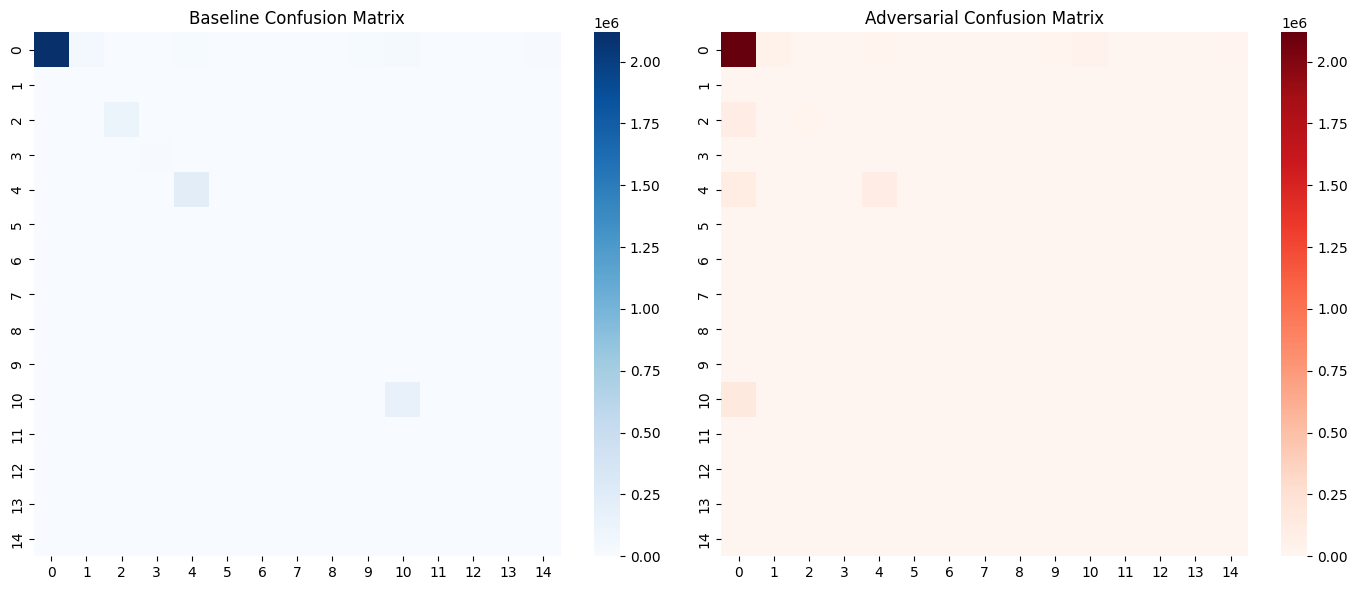

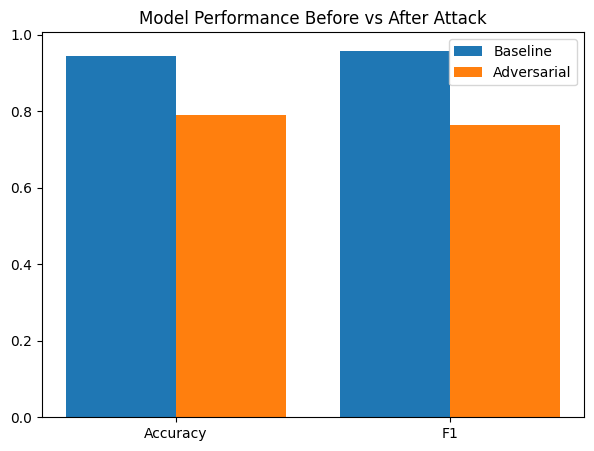


Generating perturbation distribution...


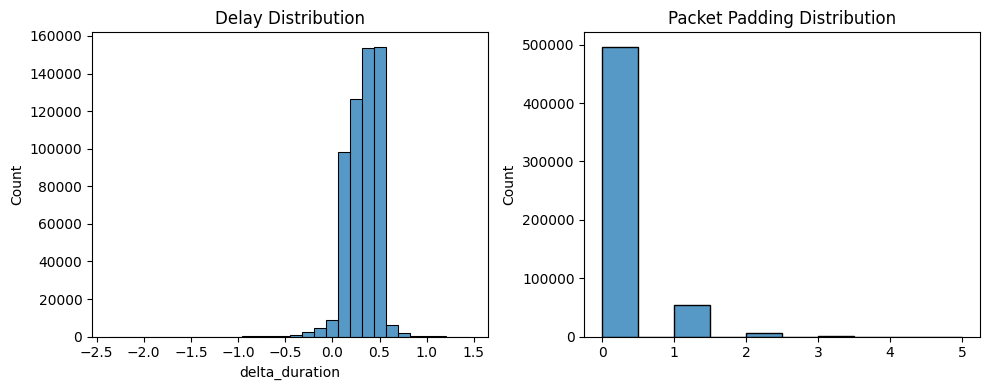

In [74]:
# Phase 3 Evaluation Pipeline


from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

all_results = results_list + false_alarm_results

print("Phase 3 Evaluation Started")

# Baseline inference (batched, GPU safe)

print("\nRunning baseline inference...")

BATCH_SIZE = 8192

baseline_preds = []

for start in range(0, len(X), BATCH_SIZE):

    batch = X[start:start+BATCH_SIZE]

    batch_tensor = torch.tensor(
        batch,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        preds = torch.argmax(
            clf.model(batch_tensor),
            dim=1
        ).cpu().numpy()

    baseline_preds.append(preds)

baseline_preds = np.concatenate(baseline_preds)

print("Baseline inference finished.")

# Generate adversarial predictions

print("\nGenerating adversarial predictions...")

adv_preds = baseline_preds.copy()

attacked_indices = [r["idx"] for r in all_results]

X_adv_subset = X[attacked_indices].copy()


for i, r in enumerate(all_results):

    X_adv_subset[i, FLOW_DURATION] += r["delta_duration"]
    X_adv_subset[i, TOTAL_FWD_PACKETS] += r["delta_fwd_pkts"]
    X_adv_subset[i, TOTAL_BWD_PACKETS] += r["delta_bwd_pkts"]
    X_adv_subset[i, FLOW_IAT_MEAN] += r["delta_iat"]




ADV_BATCH_SIZE = 8192

adv_subset_preds = []

for start in range(0, len(X_adv_subset), ADV_BATCH_SIZE):

    batch = X_adv_subset[start:start+ADV_BATCH_SIZE]

    batch_tensor = torch.tensor(
        batch,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        preds = torch.argmax(
            clf.model(batch_tensor),
            dim=1
        ).cpu().numpy()

    adv_subset_preds.append(preds)

adv_subset_preds = np.concatenate(adv_subset_preds)

for i, idx in enumerate(attacked_indices):

    adv_preds[idx] = adv_subset_preds[i]

print("Adversarial predictions finished.")

# Accuracy & F1 comparison

baseline_accuracy = accuracy_score(y, baseline_preds)
adv_accuracy = accuracy_score(y, adv_preds)

baseline_f1 = f1_score(y, baseline_preds, average="weighted")
adv_f1 = f1_score(y, adv_preds, average="weighted")

print("\nModel Performance")

print("Baseline Accuracy:", baseline_accuracy)
print("Adversarial Accuracy:", adv_accuracy)

print("Baseline F1:", baseline_f1)
print("Adversarial F1:", adv_f1)

# Attack Success Rate

success_samples = sum(r["is_success"] for r in results_list)

ASR = success_samples / len(results_list)

print("\nAttack Success Rate:", ASR)

# Detection Rate Drop

malicious_mask = (y != 0)

baseline_detect = np.sum(
    (baseline_preds != 0) & malicious_mask
) / np.sum(malicious_mask)

adv_detect = np.sum(
    (adv_preds != 0) & malicious_mask
) / np.sum(malicious_mask)

print("\nDetection Rate Before Attack:", baseline_detect)
print("Detection Rate After Attack:", adv_detect)

# Confusion Matrix

print("\nGenerating confusion matrices...")

cm_baseline = confusion_matrix(y, baseline_preds)
cm_adv = confusion_matrix(y, adv_preds)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.heatmap(cm_baseline, cmap="Blues")
plt.title("Baseline Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_adv, cmap="Reds")
plt.title("Adversarial Confusion Matrix")

plt.tight_layout()

plt.savefig("phase3_confusion_matrix.png")

plt.show()

# Performance comparison chart

metrics = ["Accuracy","F1"]

baseline_values = [
    baseline_accuracy,
    baseline_f1
]

adv_values = [
    adv_accuracy,
    adv_f1
]

x = np.arange(len(metrics))

plt.figure(figsize=(7,5))

plt.bar(x-0.2, baseline_values, 0.4, label="Baseline")
plt.bar(x+0.2, adv_values, 0.4, label="Adversarial")

plt.xticks(x, metrics)

plt.title("Model Performance Before vs After Attack")

plt.legend()

plt.savefig("phase3_performance.png")

plt.show()

# Perturbation distribution

print("\nGenerating perturbation distribution...")

df = pd.DataFrame(results_list)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["delta_duration"], bins=30)
plt.title("Delay Distribution")

plt.subplot(1,2,2)

padding = df["delta_fwd_pkts"] + df["delta_bwd_pkts"]

sns.histplot(padding, bins=10)
plt.title("Packet Padding Distribution")

plt.tight_layout()

plt.savefig("phase3_perturbation.png")

plt.show()